# EfficientNetB0 — Plant Disease Classification

This notebook evaluates **EfficientNetB0** for three-class plant disease classification:

- Healthy
- Powdery
- Rust

The experiment uses the project's predefined **training, validation, and test partitions**.

## Experimental design

1. Verify the dataset split and class distribution.
2. Apply training-only data augmentation.
3. Train a frozen ImageNet-pretrained EfficientNetB0 baseline.
4. Run one controlled fine-tuning experiment.
5. Select the final configuration **using validation data only**.
6. Recover the exact selected model weights from that experiment.
7. Evaluate the selected model once on the **unseen test set**.
8. Report classification metrics, confusion matrix, error analysis, model complexity, model size, and inference latency.
9. Save standardized CSV outputs and the final `.keras` model.

> **Test-set rule:** the test set is not used for augmentation, hyperparameter tuning, model selection, or checkpoint selection. It is used only for final evaluation.

## Final-model selection rule

The frozen and fine-tuned configurations are compared using validation results.  
The primary selection criterion is **lowest validation loss**; validation accuracy is used as a secondary indicator.

The selected configuration is then evaluated on the test set without further tuning.

In [72]:
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

CLASS_NAMES = ["Healthy", "Powdery", "Rust"]

DATASET_DIR = Path("../dataset")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = DATASET_DIR / "Train"
VAL_DIR = DATASET_DIR / "Validation"
TEST_DIR = DATASET_DIR / "Test"

def save_figure(filename):
    figure_path = RESULTS_DIR / filename
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved to:\n{figure_path.resolve()}")

print("Dataset:", DATASET_DIR.resolve())
print("Models:", MODELS_DIR.resolve())
print("Results:", RESULTS_DIR.resolve())
print("Classes:", CLASS_NAMES)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Random seed: 42
Dataset: D:\Documents\Uni Project Work\plant-disease-classification\dataset
Models: D:\Documents\Uni Project Work\plant-disease-classification\models
Results: D:\Documents\Uni Project Work\plant-disease-classification\results
Classes: ['Healthy', 'Powdery', 'Rust']
Image size: (224, 224)
Batch size: 32


In [73]:
# Load train, validation, and test datasets

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets loaded successfully.")

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.
Datasets loaded successfully.


In [74]:
print("Class names:", train_dataset.class_names)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel value range:", tf.reduce_min(images).numpy(),
          "to", tf.reduce_max(images).numpy())

Class names: ['Healthy', 'Powdery', 'Rust']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel value range: 0.0 to 255.0


In [75]:
# Verify class distributions and dataset sizes

def count_images_by_class(directory):
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = Path(directory) / class_name
        counts[class_name] = sum(
            1 for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        )
    return counts

split_counts = {
    "Train": count_images_by_class(TRAIN_DIR),
    "Validation": count_images_by_class(VAL_DIR),
    "Test": count_images_by_class(TEST_DIR),
}

distribution_df = pd.DataFrame(split_counts).T
distribution_df["Total"] = distribution_df.sum(axis=1)

print("Image counts by split and class:")
display(distribution_df)

distribution_path = RESULTS_DIR / "efficientnetb0_dataset_distribution.csv"
distribution_df.to_csv(distribution_path)

print(f"Distribution summary saved to:\n{distribution_path.resolve()}")

# Basic leakage sanity check: file paths should belong to their own split directories.
train_files = {p.resolve() for p in TRAIN_DIR.rglob("*") if p.is_file()}
val_files = {p.resolve() for p in VAL_DIR.rglob("*") if p.is_file()}
test_files = {p.resolve() for p in TEST_DIR.rglob("*") if p.is_file()}

print("\nSplit overlap checks:")
print("Train ∩ Validation:", len(train_files & val_files))
print("Train ∩ Test:", len(train_files & test_files))
print("Validation ∩ Test:", len(val_files & test_files))


Image counts by split and class:


,Healthy,Powdery,Rust,Total
Train,458,430,434,1322
Validation,20,20,20,60
Test,50,50,50,150


Distribution summary saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_dataset_distribution.csv

Split overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## EfficientNetB0 Input Pipeline

Images are loaded at **224 × 224 × 3**.

EfficientNetB0 uses ImageNet-pretrained weights. With the Keras EfficientNet implementation used here, inputs remain in their loaded **0–255** representation because the model includes its required input rescaling.

### Training-only augmentation

Augmentation is applied only while training:

- horizontal flips → different leaf orientations
- small rotations → camera/orientation variation
- small translations → different leaf positioning
- small zoom → framing/distance variation

Validation and test images are **not augmented**, so their results reflect evaluation on the original data distribution.

In [76]:
# Training augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

print(data_augmentation)

<Sequential name=data_augmentation, built=False>


In [77]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset_augmented = train_dataset.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=AUTOTUNE
)

train_dataset_augmented = train_dataset_augmented.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Training augmentation pipeline ready.")

Training augmentation pipeline ready.


In [78]:
# Load ImageNet-pretrained EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze the pretrained backbone for the baseline experiment
base_model.trainable = False

print("EfficientNetB0 loaded.")
print("Backbone trainable:", base_model.trainable)
print("Backbone output shape:", base_model.output_shape)

EfficientNetB0 loaded.
Backbone trainable: False
Backbone output shape: (None, 7, 7, 1280)


In [79]:
# Build the complete EfficientNetB0 classifier

inputs = keras.Input(shape=(224, 224, 3), name="input_image")

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.2, name="dropout")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_PlantDisease"
)

model.summary()

Model: "EfficientNetB0_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [80]:
# Parameter count

total_params = model.count_params()

trainable_params = np.sum(
    [np.prod(v.shape) for v in model.trainable_variables]
)

non_trainable_params = total_params - trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

Total parameters: 4,053,414
Trainable parameters: 3,843
Non-trainable parameters: 4,049,571


In [81]:
# Compile the frozen EfficientNetB0 baseline

LEARNING_RATE = 1e-3

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print("Learning rate:", LEARNING_RATE)
print("Optimizer: Adam")
print("Loss: SparseCategoricalCrossentropy")

Model compiled successfully.
Learning rate: 0.001
Optimizer: Adam
Loss: SparseCategoricalCrossentropy


In [82]:
# Callbacks for the frozen baseline

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

print("Callbacks configured.")

Callbacks configured.


In [83]:
# Train the frozen EfficientNetB0 baseline

EPOCHS_BASELINE = 20

start_time = time.time()

history_baseline = model.fit(
    train_dataset_augmented,
    validation_data=validation_dataset,
    epochs=EPOCHS_BASELINE,
    callbacks=[early_stopping, reduce_lr],
    shuffle=False, #data is already shuffled in the dataset
    verbose=1
)

baseline_training_time = time.time() - start_time

print(f"\nTraining time: {baseline_training_time:.2f} seconds")
print(f"Epochs actually completed: {len(history_baseline.history['loss'])}")

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 345ms/step - accuracy: 0.7806 - loss: 0.6583 - val_accuracy: 0.9500 - val_loss: 0.3255 - learning_rate: 0.0010
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.9297 - loss: 0.3290 - val_accuracy: 0.9500 - val_loss: 0.2279 - learning_rate: 0.0010
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 330ms/step - accuracy: 0.9410 - loss: 0.2397 - val_accuracy: 0.9500 - val_loss: 0.1918 - learning_rate: 0.0010
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 331ms/step - accuracy: 0.9539 - loss: 0.1989 - val_accuracy: 0.9667 - val_loss: 0.1386 - learning_rate: 0.0010
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 328ms/step - accuracy: 0.9576 - loss: 0.1801 - val_accuracy: 0.9667 - val_loss: 0.1254 - learning_rate: 0.0010
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 335ms/step - accuracy: 0.9569 - loss: 0.1605 - val_accuracy: 1.0000 - val_loss: 0.0968 - learning_rate: 0.0010
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 355ms/step - accuracy: 0.9637 - loss: 0.

Figure saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_frozen_baseline_accuracy.png


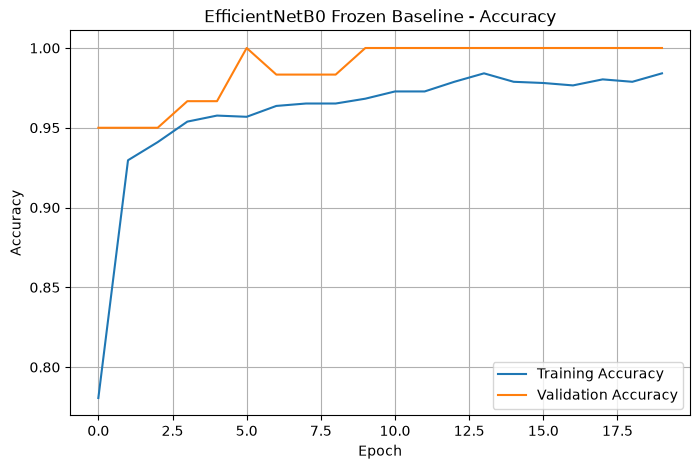

In [84]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Frozen Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
save_figure("efficientnetb0_frozen_baseline_accuracy.png")
plt.show()

Figure saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_frozen_baseline_loss.png


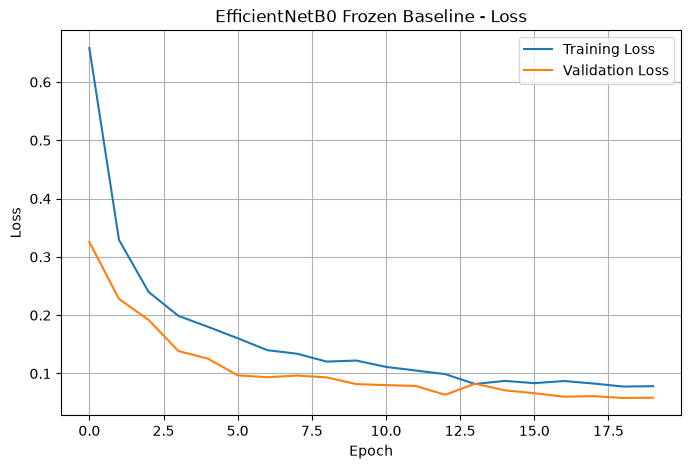

In [85]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Frozen Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
save_figure("efficientnetb0_frozen_baseline_loss.png")
plt.show()

In [86]:
# Identify the best frozen-baseline checkpoint using validation loss

baseline_best_epoch = int(
    np.argmin(history_baseline.history["val_loss"]) + 1
)

baseline_best_val_loss = float(
    np.min(history_baseline.history["val_loss"])
)

baseline_best_val_accuracy = float(
    history_baseline.history["val_accuracy"][baseline_best_epoch - 1]
)

baseline_best_train_accuracy = float(
    history_baseline.history["accuracy"][baseline_best_epoch - 1]
)

print("Frozen baseline selection metrics")
print("-" * 40)
print("Best epoch by validation loss:", baseline_best_epoch)
print(f"Best validation loss: {baseline_best_val_loss:.4f}")
print(f"Validation accuracy at selected epoch: {baseline_best_val_accuracy:.4f}")
print(f"Training accuracy at selected epoch: {baseline_best_train_accuracy:.4f}")
print(f"Training time: {baseline_training_time:.2f} seconds")

# EarlyStopping restored the best validation-loss weights.
# Save those exact weights before the model is modified for fine-tuning.
baseline_checkpoint = (
    MODELS_DIR / "efficientnetb0_frozen_best.weights.h5"
)

model.save_weights(baseline_checkpoint)

print(
    f"\nExact selected frozen-baseline weights saved to:\n"
    f"{baseline_checkpoint.resolve()}"
)

Frozen baseline selection metrics
----------------------------------------
Best epoch by validation loss: 19
Best validation loss: 0.0580
Validation accuracy at selected epoch: 1.0000
Training accuracy at selected epoch: 0.9788
Training time: 352.52 seconds

Exact selected frozen-baseline weights saved to:
D:\Documents\Uni Project Work\plant-disease-classification\models\efficientnetb0_frozen_best.weights.h5


## Controlled Fine-Tuning Experiment

The frozen model provides the transfer-learning baseline. A second experiment unfreezes only the later EfficientNetB0 layers while keeping earlier feature-extraction layers frozen.

Fine-tuning uses a much smaller learning rate (`1e-5`) than the frozen baseline (`1e-3`) to reduce the risk of damaging useful ImageNet features.

The test set is not consulted when deciding whether fine-tuning is preferable.


In [87]:
# Enable fine-tuning

base_model.trainable = True

# Freeze the earlier layers and fine-tune the later layers
fine_tune_from = 200

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

print("Total backbone layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_from)

trainable_backbone = sum(
    layer.trainable for layer in base_model.layers
)

print("Trainable backbone layers:", trainable_backbone)

Total backbone layers: 238
Fine-tuning from layer: 200
Trainable backbone layers: 38


In [88]:
total_params_ft = model.count_params()

trainable_params_ft = np.sum(
    [np.prod(v.shape) for v in model.trainable_variables]
)

non_trainable_params_ft = total_params_ft - trainable_params_ft

print(f"Total parameters: {total_params_ft:,}")
print(f"Trainable parameters: {trainable_params_ft:,}")
print(f"Non-trainable parameters: {non_trainable_params_ft:,}")

Total parameters: 4,053,414
Trainable parameters: 2,054,547
Non-trainable parameters: 1,998,867


In [89]:
FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Fine-tuning model compiled.")
print("Learning rate:", FINE_TUNE_LR)

Fine-tuning model compiled.
Learning rate: 1e-05


In [90]:
fine_tune_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

fine_tune_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

print("Fine-tuning callbacks configured.")

Fine-tuning callbacks configured.


In [109]:
FINE_TUNE_EPOCHS = 15

start_time = time.time()

history_fine_tune = model.fit(
    train_dataset_augmented,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ],
    shuffle=False, #data is already shuffled in the dataset
    verbose=1
)

fine_tune_training_time = time.time() - start_time

print(f"\nFine-tuning time: {fine_tune_training_time:.2f} seconds")
print(
    "Epochs actually completed:",
    len(history_fine_tune.history["loss"])
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 372ms/step - accuracy: 0.9100 - loss: 0.2821 - val_accuracy: 0.9667 - val_loss: 0.1327 - learning_rate: 4.0000e-07
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 400ms/step - accuracy: 0.9115 - loss: 0.2699 - val_accuracy: 0.8833 - val_loss: 0.2099 - learning_rate: 4.0000e-07
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 377ms/step - accuracy: 0.9183 - loss: 0.2616 - val_accuracy: 0.8667 - val_loss: 0.2694 - learning_rate: 4.0000e-07
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 375ms/step - accuracy: 0.9244 - loss: 0.2589 - val_accuracy: 0.8500 - val_loss: 0.3099 - learning_rate: 1.0000e-07
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 381ms/step - accuracy: 0.9123 - loss: 0.2704 - val_accuracy: 0.8333 - val_loss: 0.3387 - learning_rate: 1.0000e-07
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 374ms/step - accuracy: 0.9342 - loss: 0.2471 - val_accuracy: 0.8333 - val_loss: 0.3550 - learning_rate: 1.0000e-07

Fine-tuning time: 100.67 seconds
Epochs actually complete

Figure saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_fine_tuning_accuracy.png


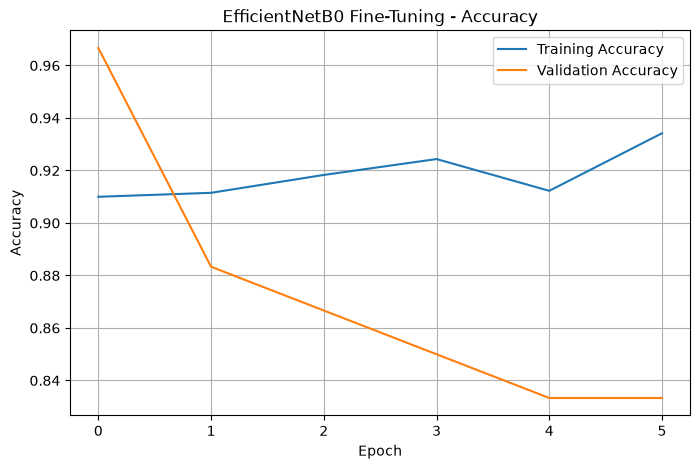

In [110]:
# Fine-tuning accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fine_tune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
save_figure("efficientnetb0_fine_tuning_accuracy.png")
plt.show()

Figure saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_fine_tuning_loss.png


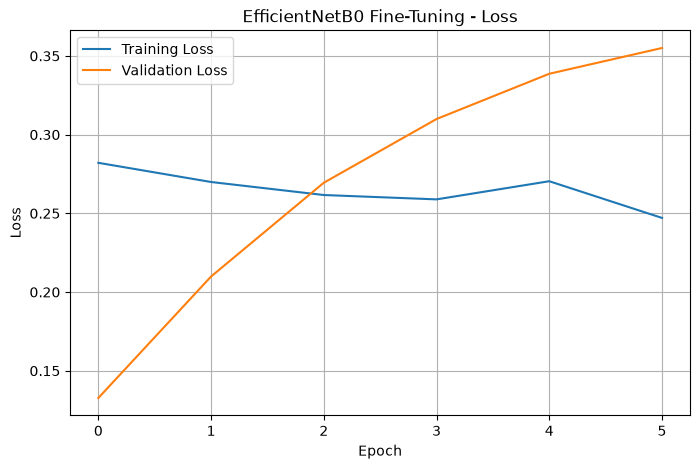

In [111]:
# Fine-tuning loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tune.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fine_tune.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
save_figure("efficientnetb0_fine_tuning_loss.png")
plt.show()

In [112]:
best_ft_epoch = int(
    np.argmin(history_fine_tune.history["val_loss"]) + 1
)

best_ft_val_loss = float(
    np.min(history_fine_tune.history["val_loss"])
)

best_ft_val_accuracy = float(
    history_fine_tune.history["val_accuracy"][best_ft_epoch - 1]
)

print("EfficientNetB0 Fine-Tuning Summary")
print("-" * 40)
print("Best epoch by validation loss:", best_ft_epoch)
print(f"Best validation loss: {best_ft_val_loss:.4f}")
print(f"Validation accuracy at selected epoch: {best_ft_val_accuracy:.4f}")
print(f"Fine-tuning time: {fine_tune_training_time:.2f} seconds")
print(
    "Epochs completed:",
    len(history_fine_tune.history["loss"])
)

# EarlyStopping restored the best validation-loss weights.
fine_tune_checkpoint = (
    MODELS_DIR / "efficientnetb0_finetuned_best.weights.h5"
)

model.save_weights(fine_tune_checkpoint)

print(
    f"\nExact selected fine-tuning weights saved to:\n"
    f"{fine_tune_checkpoint.resolve()}"
)

EfficientNetB0 Fine-Tuning Summary
----------------------------------------
Best epoch by validation loss: 1
Best validation loss: 0.1327
Validation accuracy at selected epoch: 0.9667
Fine-tuning time: 100.67 seconds
Epochs completed: 6

Exact selected fine-tuning weights saved to:
D:\Documents\Uni Project Work\plant-disease-classification\models\efficientnetb0_finetuned_best.weights.h5


In [113]:
# EfficientNetB0 experiment comparison

experiment_comparison = pd.DataFrame([
    {
        "experiment_id": "ENB0-EXP-01",
        "configuration": "Frozen baseline",
        "backbone_trainable_layers": 0,
        "learning_rate": LEARNING_RATE,
        "best_val_accuracy": baseline_best_val_accuracy,
        "best_val_loss": baseline_best_val_loss,
        "best_epoch": baseline_best_epoch,
        "epochs_completed": len(history_baseline.history["loss"]),
        "training_time_seconds": baseline_training_time,
        "training_time_minutes": baseline_training_time / 60,
    },
    {
        "experiment_id": "ENB0-EXP-02",
        "configuration": "Fine-tuned later layers",
        "backbone_trainable_layers": trainable_backbone,
        "learning_rate": FINE_TUNE_LR,
        "best_val_accuracy": best_ft_val_accuracy,
        "best_val_loss": best_ft_val_loss,
        "best_epoch": best_ft_epoch,
        "epochs_completed": len(history_fine_tune.history["loss"]),
        "training_time_seconds": fine_tune_training_time,
        "training_time_minutes": fine_tune_training_time / 60,
    }
])

experiment_comparison_path = (
    RESULTS_DIR / "efficientnetb0_experiment_comparison.csv"
)

experiment_comparison.to_csv(
    experiment_comparison_path,
    index=False
)

print("EfficientNetB0 Experiment Comparison")
print("=" * 60)
display(experiment_comparison)

print(
    f"\nSaved experiment comparison to:\n"
    f"{experiment_comparison_path.resolve()}"
)

# Validation-only model selection.
# Lower validation loss is the primary criterion; validation accuracy
# is a secondary indicator.
if best_ft_val_loss < baseline_best_val_loss:
    selected_configuration = "Fine-tuned later layers"
    selected_checkpoint = fine_tune_checkpoint
    selected_learning_rate = FINE_TUNE_LR
    selected_history = history_fine_tune
    selected_best_val_accuracy = best_ft_val_accuracy
    selected_best_val_loss = best_ft_val_loss
    selected_best_epoch = best_ft_epoch
    selected_epochs_completed = len(history_fine_tune.history["loss"])
    selected_training_time = fine_tune_training_time
    selected_checkpoint_description = "fine-tuned experiment best weights"
else:
    selected_configuration = "Frozen ImageNet backbone"
    selected_checkpoint = baseline_checkpoint
    selected_learning_rate = LEARNING_RATE
    selected_history = history_baseline
    selected_best_val_accuracy = baseline_best_val_accuracy
    selected_best_val_loss = baseline_best_val_loss
    selected_best_epoch = baseline_best_epoch
    selected_epochs_completed = len(history_baseline.history["loss"])
    selected_training_time = baseline_training_time
    selected_checkpoint_description = "frozen baseline best weights"

print("\nSelected final configuration:", selected_configuration)
print("Selection criterion: lowest validation loss")
print("Selected learning rate:", selected_learning_rate)
print("Selected checkpoint:", selected_checkpoint.resolve())
print("No test-set information was used for this decision.")


EfficientNetB0 Experiment Comparison


,experiment_id,configuration,backbone_trainable_layers,learning_rate,best_val_accuracy,best_val_loss,best_epoch,epochs_completed,training_time_seconds,training_time_minutes
0,ENB0-EXP-01,Frozen baseline,0,0.00100,1.000000,0.057979,19,20,352.521142,5.875352
1,ENB0-EXP-02,Fine-tuned later layers,38,0.00001,0.966667,0.132694,1,6,100.669556,1.677826



Saved experiment comparison to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_experiment_comparison.csv

Selected final configuration: Frozen ImageNet backbone
Selection criterion: lowest validation loss
Selected learning rate: 0.001
Selected checkpoint: D:\Documents\Uni Project Work\plant-disease-classification\models\efficientnetb0_frozen_best.weights.h5
No test-set information was used for this decision.


## Recover the Selected Model Without Retraining

The selected configuration is determined from validation loss. Reconstructs the selected architecture and loads the **exact best weights** saved during the corresponding experiment.

This avoids mixing metrics from different training runs and preserves a reproducible link between model selection and final test evaluation.

In [114]:
# Rebuild the selected final EfficientNetB0 architecture

base_model_final = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3)
)

if selected_configuration == "Frozen ImageNet backbone":
    base_model_final.trainable = False
else:
    base_model_final.trainable = True

    for layer in base_model_final.layers[:fine_tune_from]:
        layer.trainable = False

    for layer in base_model_final.layers[fine_tune_from:]:
        layer.trainable = True

inputs_final = keras.Input(
    shape=(*IMAGE_SIZE, 3),
    name="input_image"
)

x = base_model_final(inputs_final, training=False)
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)
x = layers.Dropout(
    0.2,
    name="dropout"
)(x)

outputs_final = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

final_model = keras.Model(
    inputs=inputs_final,
    outputs=outputs_final,
    name="EfficientNetB0_PlantDisease_Final"
)

# Load the selected model weights first.
final_model.load_weights(selected_checkpoint)

# Compile only after loading weights.
final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=selected_learning_rate
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Selected final model reconstructed.")
print("Configuration:", selected_configuration)
print("Backbone trainable:", base_model_final.trainable)
print("Loaded weights:", selected_checkpoint.resolve())

Selected final model reconstructed.
Configuration: Frozen ImageNet backbone
Backbone trainable: False
Loaded weights: D:\Documents\Uni Project Work\plant-disease-classification\models\efficientnetb0_frozen_best.weights.h5


In [115]:
# Save the selected configuration's training history

training_history = pd.DataFrame({
    "epoch": np.arange(
        1,
        len(selected_history.history["loss"]) + 1
    ),
    "loss": selected_history.history["loss"],
    "accuracy": selected_history.history["accuracy"],
    "val_loss": selected_history.history["val_loss"],
    "val_accuracy": selected_history.history["val_accuracy"],
})

training_history_path = (
    RESULTS_DIR / "efficientnetb0_training_history.csv"
)

training_history.to_csv(
    training_history_path,
    index=False
)

print(
    f"Selected training history saved to:\n"
    f"{training_history_path.resolve()}"
)

Selected training history saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_training_history.csv


In [116]:
# Final evaluation on the untouched test set

test_loss, test_accuracy = final_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.9600 - loss: 0.1092
Test loss: 0.1092
Test accuracy: 0.9600


In [117]:
# Generate predictions for the test set

y_true = []
y_pred = []
y_prob = []

for images, labels in test_dataset:
    probabilities = final_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

True labels: (150,)
Predictions: (150,)
Probabilities: (150, 3)


In [118]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [119]:
# Classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)


# Save classification report as CSV

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

classification_report_df = pd.DataFrame(
    report_dict
).transpose()

classification_report_path = (
    RESULTS_DIR / "efficientnetb0_classification_report.csv"
)

classification_report_df.to_csv(
    classification_report_path
)

print(
    f"\nClassification report saved to:\n"
    f"{classification_report_path.resolve()}"
)


              precision    recall  f1-score   support

     Healthy     0.9400    0.9400    0.9400        50
     Powdery     0.9400    0.9400    0.9400        50
        Rust     1.0000    1.0000    1.0000        50

    accuracy                         0.9600       150
   macro avg     0.9600    0.9600    0.9600       150
weighted avg     0.9600    0.9600    0.9600       150


Classification report saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_classification_report.csv


In [120]:
test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true, y_pred, average="weighted"
)

test_recall = recall_score(
    y_true, y_pred, average="weighted"
)

test_f1 = f1_score(
    y_true, y_pred, average="weighted"
)

macro_precision = precision_score(
    y_true, y_pred, average="macro"
)

macro_recall = recall_score(
    y_true, y_pred, average="macro"
)

macro_f1 = f1_score(
    y_true, y_pred, average="macro"
)

test_roc_auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy:            {test_accuracy:.4f}")
print(f"Weighted Precision:   {test_precision:.4f}")
print(f"Weighted Recall:      {test_recall:.4f}")
print(f"Weighted F1:          {test_f1:.4f}")
print(f"Macro Precision:      {macro_precision:.4f}")
print(f"Macro Recall:         {macro_recall:.4f}")
print(f"Macro F1:             {macro_f1:.4f}")
print(f"Weighted ROC-AUC:     {test_roc_auc:.4f}")

Accuracy:            0.9600
Weighted Precision:   0.9600
Weighted Recall:      0.9600
Weighted F1:          0.9600
Macro Precision:      0.9600
Macro Recall:         0.9600
Macro F1:             0.9600
Weighted ROC-AUC:     0.9965


In [121]:
# Confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)


# Save confusion matrix as CSV

confusion_matrix_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

confusion_matrix_path = (
    RESULTS_DIR / "efficientnetb0_confusion_matrix.csv"
)

confusion_matrix_df.to_csv(
    confusion_matrix_path
)

print(
    f"\nConfusion matrix saved to:\n"
    f"{confusion_matrix_path.resolve()}"
)


Confusion Matrix:
[[47  3  0]
 [ 3 47  0]
 [ 0  0 50]]

Confusion matrix saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_confusion_matrix.csv


Figure saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_confusion_matrix.png


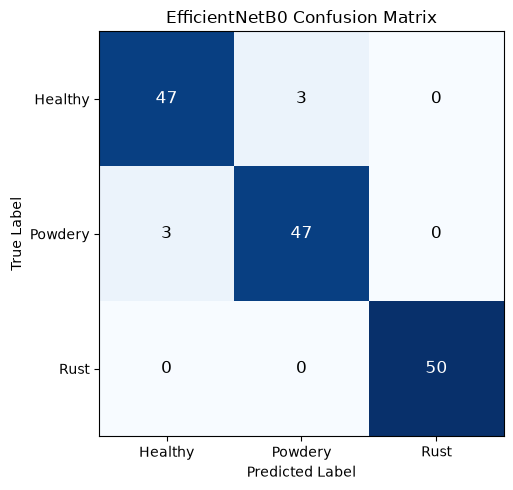

In [122]:
plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)

plt.tight_layout()
save_figure("efficientnetb0_confusion_matrix.png")
plt.show()

## Error Analysis

The confusion matrix shows aggregate error patterns. The following section inspects individual misclassified test images so that the model's failure cases can be discussed using evidence.


Total misclassified test images: 6
Misclassification details saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_misclassifications.csv


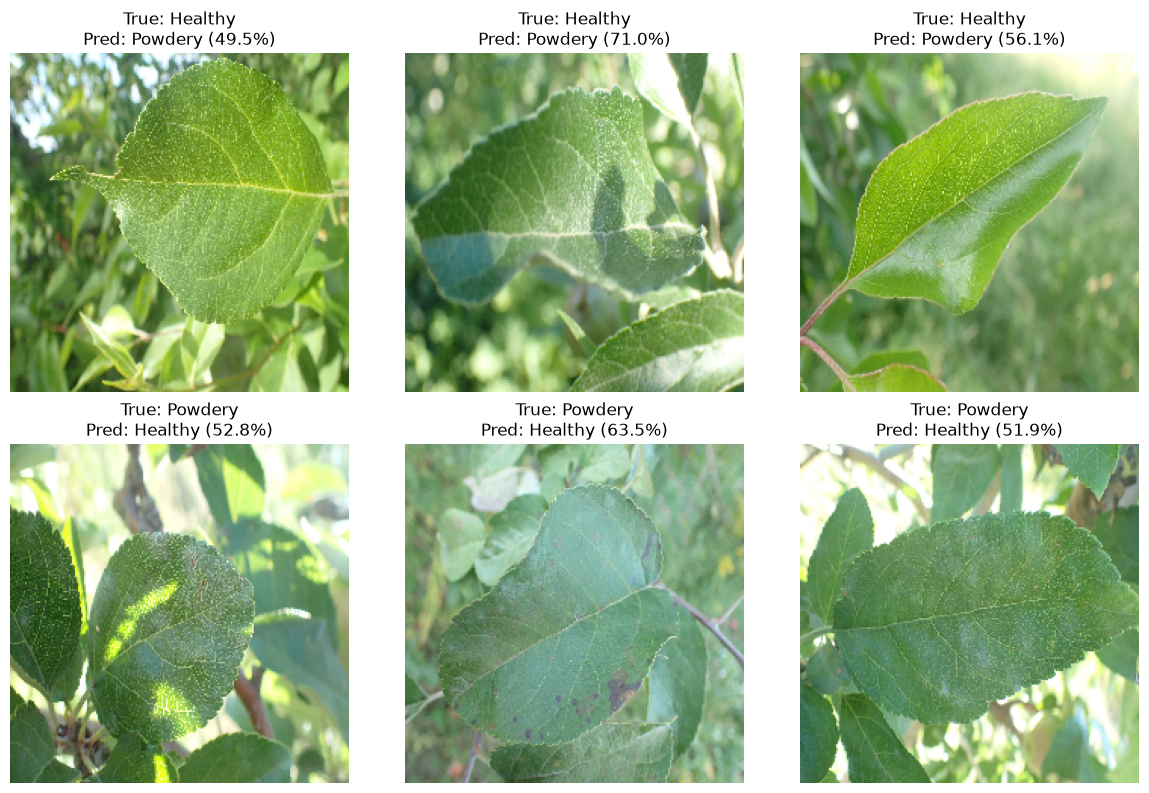

In [123]:
# Display a sample of misclassified test images

misclassified_images = []
misclassified_records = []

for images, labels in test_dataset:
    probabilities = final_model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    images_np = images.numpy()

    for image, true_label, predicted_label, probs in zip(
        images_np,
        labels.numpy(),
        predictions,
        probabilities
    ):
        if int(true_label) != int(predicted_label):
            misclassified_images.append(image)
            misclassified_records.append({
                "true_class": CLASS_NAMES[int(true_label)],
                "predicted_class": CLASS_NAMES[int(predicted_label)],
                "confidence": float(np.max(probs)),
                "healthy_probability": float(probs[0]),
                "powdery_probability": float(probs[1]),
                "rust_probability": float(probs[2]),
            })

print("Total misclassified test images:", len(misclassified_images))

misclassification_df = pd.DataFrame(misclassified_records)

misclassification_path = (
    RESULTS_DIR / "efficientnetb0_misclassifications.csv"
)

misclassification_df.to_csv(
    misclassification_path,
    index=False
)

print(
    f"Misclassification details saved to:\n"
    f"{misclassification_path.resolve()}"
)

if len(misclassified_images) == 0:
    print("No misclassified test images were found.")
else:
    n_show = min(12, len(misclassified_images))
    cols = 3
    rows = int(np.ceil(n_show / cols))

    plt.figure(figsize=(12, 4 * rows))

    for i in range(n_show):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(
            np.clip(
                misclassified_images[i].astype(np.uint8),
                0,
                255
            )
        )

        record = misclassified_records[i]

        plt.title(
            f"True: {record['true_class']}\n"
            f"Pred: {record['predicted_class']} "
            f"({record['confidence']:.1%})"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


## Computational Efficiency and Model Complexity

The assignment asks the model comparison to consider computational efficiency and model complexity in addition to predictive performance.

The following measurements are saved for use in the cross-model comparison:

- total parameters
- trainable parameters
- saved model size
- average single-image inference latency


In [124]:
# Save the selected final model

# Keep the frozen filename for the currently selected configuration so the
# Streamlit application can load the final EfficientNetB0 model consistently.
if selected_configuration == "Frozen ImageNet backbone":
    final_model_filename = "efficientnetb0_frozen_final.keras"
else:
    final_model_filename = "efficientnetb0_finetuned_final.keras"

FINAL_MODEL_PATH = MODELS_DIR / final_model_filename

final_model.save(FINAL_MODEL_PATH)

model_size_mb = (
    FINAL_MODEL_PATH.stat().st_size / (1024 ** 2)
)

print(
    f"Final EfficientNetB0 model saved to:\n"
    f"{FINAL_MODEL_PATH.resolve()}"
)
print(f"Model size: {model_size_mb:.2f} MB")


Final EfficientNetB0 model saved to:
D:\Documents\Uni Project Work\plant-disease-classification\models\efficientnetb0_frozen_final.keras
Model size: 16.27 MB


In [125]:
# Measure average single-image inference latency

# Warm-up run so graph tracing/loading overhead is not included.
sample_batch = next(iter(test_dataset))
sample_image = sample_batch[0][0:1]

_ = final_model.predict(sample_image, verbose=0)

latency_runs = 20
latency_values = []

for _ in range(latency_runs):
    start = time.perf_counter()
    _ = final_model.predict(sample_image, verbose=0)
    latency_values.append(time.perf_counter() - start)

average_latency_ms = float(np.mean(latency_values) * 1000)
latency_std_ms = float(np.std(latency_values) * 1000)

print(f"Average single-image inference latency: {average_latency_ms:.2f} ms")
print(f"Latency standard deviation: {latency_std_ms:.2f} ms")
print(f"Measurement runs: {latency_runs}")


Average single-image inference latency: 73.19 ms
Latency standard deviation: 4.46 ms
Measurement runs: 20


In [126]:
# Final EfficientNetB0 test results

final_results = pd.DataFrame([{
    "model": "EfficientNetB0",
    "configuration": selected_configuration,

    "test_samples": len(y_true),

    "test_loss": test_loss,
    "accuracy": test_accuracy,
    "weighted_precision": test_precision,
    "weighted_recall": test_recall,
    "weighted_f1": test_f1,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_roc_auc": test_roc_auc,

    "best_val_accuracy": selected_best_val_accuracy,
    "best_val_loss": selected_best_val_loss,
    "best_val_epoch": selected_best_epoch,

    "epochs_completed": selected_epochs_completed,

    "training_time_seconds": selected_training_time,
    "training_time_minutes": selected_training_time / 60,

    "total_parameters": final_model.count_params(),

    "trainable_parameters": sum(
        np.prod(v.shape)
        for v in final_model.trainable_variables
    ),

    "model_size_mb": model_size_mb,
    "average_inference_latency_ms": average_latency_ms,
    "inference_latency_std_ms": latency_std_ms,
    "random_seed": SEED,
}])

final_results_path = (
    RESULTS_DIR / "efficientnetb0_final_results.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print("EfficientNetB0 Final Test Results")
print("-" * 50)

display(final_results)

print(
    f"\nFinal results saved to:\n"
    f"{final_results_path.resolve()}"
)

EfficientNetB0 Final Test Results
--------------------------------------------------


,model,configuration,test_samples,test_loss,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,...,best_val_epoch,epochs_completed,training_time_seconds,training_time_minutes,total_parameters,trainable_parameters,model_size_mb,average_inference_latency_ms,inference_latency_std_ms,random_seed
0,EfficientNetB0,Frozen ImageNet backbone,150,0.109215,0.96,0.96,0.96,0.96,0.96,0.96,...,19,20,352.521142,5.875352,4053414,3843,16.274635,73.189045,4.455589,42



Final results saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_final_results.csv
